# This file calculates the equilibrium CT and the equilibrium sCT levels

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:miniforge3-py38" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages(import_spline=False))
misc_params = Params.additional_misc_params()

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = False
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the CT variable that will serve as the comparison for the CT_equil - and its temporal resolution

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = 'dissic'
depth_to_analyze = 'surface'
temporal_resolution = 'annual_means'

Choosing variable and temporal resolution....


## Get the model CT data

In [5]:
print("Opening the variable's model dataset...")
run_paths = ModelDataGetter._identify_path_strings(run_params,variable_to_analyze,depth_to_analyze)
ds_data   = ModelDataGetter._open_datasets(run_paths)

Opening the variable's model dataset...


## Convert CT from volumetric to gravimetric units

In [6]:
print('Convert data from volumetric concentrations to gravimetric concentrations (loading density internally) .... Attention: resoluts are put again into ds_data.')
ds_data = Converter._convert_from_mol_per_m3_to_mumol_per_kg(run_params,ds_data,temporal_resolution,depth_to_analyze)


Convert data from volumetric concentrations to gravimetric concentrations (loading density internally) .... Attention: resoluts are put again into ds_data.


## Get the additional ocean mask, area weights, atmospheric CO2, and ocean regions

In [7]:
print('Getting miscellaneous data...')
da_omask  = MiscDataGetter._get_ocean_mask()
da_area   = MiscDataGetter._get_grid_cell_areas()
ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
ds_oregs, reg_lookup_dict  = MiscDataGetter._get_ocean_regions()

Getting miscellaneous data...
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2
james' way to define atm. xco2


## Compute the CT equilibrium using pyCO2sys

In [8]:
# load the pyCO2SYS package
import PyCO2SYS as pyco2
pyco2.hello() # print the version

def get_data(run_params,key,varia,depth_to_analyze,temporal_resolution, yr, step):

    # indicate from which models we get the nutrient field - for the others use World Ocean Atlas (WOA) climatological nutrients
    model_nutrients = ['CNRM-ESM2-1','NorESM2-LM']

    # get the non-model fields (namely for nutriets if it is not CNRM or NorESM
    if varia in ['po4','si'] and run_params[key].model not in model_nutrients:
    
        # get the nutrient data from WOA
        #print('need to get woa data')

        if varia == 'po4':
            ds_po4 = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/phosphate/annual/woa23_all_p00_01_remapped.nc',decode_times=False)
            da_po4 = ds_po4['p_an'].isel(depth=0).squeeze() #in mumol/kg
            extracted_data = da_po4.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        elif varia == 'si':
            ds_si = xr.open_dataset('/data/ekoehn/world_ocean_atlas/woa2023/silicate/annual/woa23_all_i00_01_remapped.nc',decode_times=False)
            da_si = ds_si['i_an'].isel(depth=0).squeeze() #in mumol/kg      
            extracted_data = da_si.expand_dims({'year': step}).transpose('year', 'lat', 'lon')
            extracted_data = extracted_data.assign_coords(year=("year", 1850 + np.arange(yr,yr+step)))
        else:
            raise Exception('unknown variable')      

    # get the model data
    else:

        # gets the list of files for all runs for this variable
        run_paths = ModelDataGetter._identify_path_strings(run_params,varia,depth_to_analyze,verbose=False) 
    
        # select the run for the chosen key, open from file, extract the variable
        with xr.open_dataset(run_paths[key]) as ds_data: 
            extracted_data = ds_data[temporal_resolution].isel(year=slice(yr, yr+step)) #extract_data_helper(ds_data,temporal_resolution,yr,step)
            extracted_data.load()  # Load into memory before file closes

        # convert alkalinity data and the nutrient data loaded from the models (WOA data already in right mumol per kg format)
        if varia in ['talk','po4','si']:
            #print('convert unit from volumetric to gravimetric (loading density internally) - from mol per m3 to mumol per kg')
            dens_paths = ModelDataGetter._identify_path_strings(run_params,'denis',depth_to_analyze) 
            with xr.open_dataset(dens_paths[key]) as dens_data: 
                extracted_dens = dens_data[temporal_resolution].isel(year=slice(yr, yr+step))
                conv_factor = Converter._Converter__conversion_factors('from_per_m3_to_per_kg',extracted_dens) * Converter._Converter__conversion_factors('from_1_to_micro')
                extracted_data = extracted_data * conv_factor              

    return extracted_data

def get_pressure_data(run_params,key,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape
    
    # get the depth data
    if run_params[key].model == 'CESM2':
        depth = (t_data.lev/100).values
    else:
        depth = t_data.lev.values

    # get the longitude and latitude data
    lon = t_data.lon #.values
    lat = t_data.lat #.values

    # get the fully 3d lat and depth arrays
    lat3D = t_data['lat'].expand_dims({'year': YEARS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    depth3D = xr.DataArray(depth, dims=()).expand_dims({'year': YEARS, 'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')

    # compute the pressure using the gsw toolbox
    pressure = gsw.p_from_z(-depth3D, lat3D)  # in dbar
    
    return pressure

def get_atmospheric_CO2_data(run_params,key,yr,step,t_data):

    # get the shape of t_data
    YEARS,LATS,LONS = t_data.shape

    # get xco2 data and make it 3D
    ds_atmCO2 = MiscDataGetter._get_atmospheric_CO2(run_params)
    xco2 = ds_atmCO2[key].isel(year=slice(yr,yr+step))
    xco2_3D = xr.DataArray(xco2, dims=('year')).expand_dims({'lat': LATS, 'lon': LONS}).transpose('year', 'lat', 'lon')
    #print(xco2_3D.shape)

    # now convert to pco2
    factor_to_convert_from_hPa_to_atm = 1/1013.25   # 1 atm = 1013.25 hPa  
    factor_to_convert_from_atm_to_muatm = 10**6   # 
    factor_to_convert_from_hPa_to_muatm = factor_to_convert_from_hPa_to_atm*factor_to_convert_from_atm_to_muatm
    water_vapor_pressure = 0 #6.1 #30#6.1 #hPa
    surface_level_atmospheric_pressure = 1013.25 #980 #1013.25 # hPa
    factor_to_convert_from_ppm = 10**(-6)
    pco2 = xco2_3D*factor_to_convert_from_ppm*(surface_level_atmospheric_pressure-water_vapor_pressure)*factor_to_convert_from_hPa_to_muatm # in ppm * hPa 

    return pco2


def process_year_block(key, yr, step, run_params, depth_to_analyze, temporal_resolution):

    print(f'processing years {yr}-{yr+step-1}')
    
    run_func = True

    # need to get the data for: T, S, AT, PO4, SI, pCO2, PRESSURE (DEPTH)
    t    = get_data(run_params,key,'thetao',depth_to_analyze, temporal_resolution, yr, step) # model # in °C (pot temp)
    s    = get_data(run_params,key,'so',    depth_to_analyze, temporal_resolution, yr, step) # model # in psu
    alk  = get_data(run_params,key,'talk',  depth_to_analyze, temporal_resolution, yr, step) # model # in mumol/kg
    po4  = get_data(run_params,key,'po4',   depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 
    si   = get_data(run_params,key,'si',    depth_to_analyze, temporal_resolution, yr, step) # model or WOA2023 dependent on availability # in mumol/kg 

    # get the pressure data
    pressure = get_pressure_data(run_params,key,t) # converted from depth and latitude # in dbar

    #print(pressure.shape)
    
    # get the atmospheric CO2 data
    pco2 = get_atmospheric_CO2_data(run_params,key,yr,step,t) # convert from prescribed atmospheric mixing ratio (using sea level pressure and relative humidity) # in ppm * hPa (muatm)

    #print(pco2.shape)

    # choose the options for pyCO2sys
    opt_gas_constant=3
    opt_k_bisulfate=1
    opt_k_carbonic=15 # 15: Waters et al. 2014;           10: Lueker et al. 2010 (LDK00)
    opt_k_fluoride=1
    opt_pH_scale=1
    opt_total_borate=1
    opt_buffers_mode=1

    # run the pyCO2sys routine (need to flatten the arrays for passing to function)
    if run_func:
        pyCO2sys_results = pyco2.sys(
                        par1=alk.values.flatten(), 
                        par2=pco2.values.flatten(),
                        par1_type=1, 
                        par2_type=4,
                        salinity=s.values.flatten(),
                        temperature=t.values.flatten(),  
                        pressure=pressure.values.flatten(), 
                        temperature_out=t.values.flatten(),
                        pressure_out=pressure.values.flatten(), 
                        total_phosphate=po4.values.flatten(), 
                        total_silicate=si.values.flatten(),
                        opt_gas_constant=opt_gas_constant,
                        opt_k_bisulfate=opt_k_bisulfate,
                        opt_k_carbonic=opt_k_carbonic,
                        opt_k_fluoride=opt_k_fluoride,
                        opt_pH_scale=opt_pH_scale,
                        opt_total_borate=opt_total_borate,
                        opt_buffers_mode=opt_buffers_mode,
                     )

        # reshape the results from pyCO2sys
        reshaped_pyCO2sys_results = pyCO2sys_results['dic'].reshape(t.shape) 

        # put it into an xarray DataArray with the same dimensions and coordinates as for the example temperature
        da_pyCO2sys_result = xr.DataArray(reshaped_pyCO2sys_results, dims=t.dims, coords=t.coords, name="CT_equilibrium")              
        
        return da_pyCO2sys_result
    else:
        return t,s,alk,po4,si,pressure,pco2


def calc_CT_equil(run_params,depth_to_analyze,temporal_resolution):

    # initialize the dictionary for the output
    CT_equil = dict()

    # loop over the model runs to do the calculation for each model
    for key in run_params.keys():
        print(f'Computing the equilibrium CT for model: {run_params[key].model} (key {key})')

        # Do the calculation in a parallelized fashion for speedier performance
        start_year = 0
        end_year = 340
        step = 5
        years = list(range(start_year, end_year, step))
        da_pyCO2sys_result = Parallel(n_jobs=10)(delayed(process_year_block)(key, yr, step, run_params, depth_to_analyze, temporal_resolution) for yr in years)
        concatenated_pyCO2sys_results = xr.concat(da_pyCO2sys_result, dim='year')

        # put the concatenated dataarray into a dataset - this keeps consitency with the CT data
        ds_pyCO2sys_result = xr.Dataset({temporal_resolution: concatenated_pyCO2sys_results})

        # add the unit of the CT_equilibrium
        ds_pyCO2sys_result.attrs["unit"] = "mumol kg-1"
        
        # put the dataset into the dictionary
        CT_equil[key] = ds_pyCO2sys_result

    return CT_equil


CT_equil = calc_CT_equil(run_params,depth_to_analyze,temporal_resolution)


               M.P. Humphreys, A.J. Schiller, D.E. Sandborn,
                L. Gregor, D. Pierrot, S.M.A.C. van Heuven,
                        E.R. Lewis & D.W.R. Wallace

                             ~~~ present ~~~

        PyCO2SYS: marine carbonate system calculations in Python.
               Version 1.8.3 :: doi:10.5281/zenodo.3744275


  Py  CCCC       OOOOO        222        SSS      YY      YY      SSS
     CC   C     OO   OO     22   22    SS   SS     YY    YY     SS   SS
    CC         OO     OO         22    SS           YY  YY      SS
    CC         OO     OO        22        S           YY          SSS
    CC         OO     OO       22           SS        YY             SS
     CC   C     OO   OO      22        SS   SS        YY        SS   SS
      CCCC       OOOOO      2222222      SSS          YY          SSS


   Lasciate ogni speranza, voi ch' entrate!
                                    Dante, Inferno iii, 9
                                    sign on the entranc

## Now that we have calculate CT_equil, we compute sCT_equil and sCT (by normalizing with salinity)

In [9]:
print('Normalize with salinity.')
ds_data_sal_norm, variable_to_analyze_sal_norm = Converter._normalize_with_salinity(run_params,ds_data,temporal_resolution,depth_to_analyze,variable_to_analyze,standard_salinity=misc_params.standard_salinity)
CT_equil_sal_norm, variable_to_analyze_sal_norm = Converter._normalize_with_salinity(run_params,CT_equil,temporal_resolution,depth_to_analyze,variable_to_analyze,standard_salinity=misc_params.standard_salinity)


Normalize with salinity.


## Now, choose some regions and calculate the regional means

In [10]:
set_of_loc_reg_2 = ['Global Ocean','Arctic Ocean','Barents Sea','central Arctic']
print('Chosen locations: ', set_of_loc_reg_2)

print('Compute the regional means for the full CT and CT_equil .....')
CT_reg_mean = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,ds_data,temporal_resolution)
CT_equil_reg_mean = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,CT_equil,temporal_resolution)

print('Compute the regional means for the salinity normalized sCT and sCT_equil .....')
sCT_reg_mean = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,ds_data_sal_norm,temporal_resolution)
sCT_equil_reg_mean = MMFuncs._calc_regional_means(run_params,set_of_loc_reg_2,CT_equil_sal_norm,temporal_resolution)

Chosen locations:  ['Global Ocean', 'Arctic Ocean', 'Barents Sea', 'central Arctic']
Compute the regional means for the full CT and CT_equil .....
Compute the regional means for the salinity normalized sCT and sCT_equil .....


## Compute the disequilibrium

In [11]:
print('Compute the disequilibrium by subtracting the equilibrium CT levels from the actual ones.....')
CT_diseq_reg_mean = dict()
sCT_diseq_reg_mean = dict()
for loc_reg in set_of_loc_reg_2:
    CT_diseq_reg_mean[loc_reg] = CT_reg_mean[loc_reg] - CT_equil_reg_mean[loc_reg]
    sCT_diseq_reg_mean[loc_reg] = sCT_reg_mean[loc_reg] - sCT_equil_reg_mean[loc_reg]

Compute the disequilibrium by subtracting the equilibrium CT levels from the actual ones.....


## Now plot the CT and sCT disequilibrium 

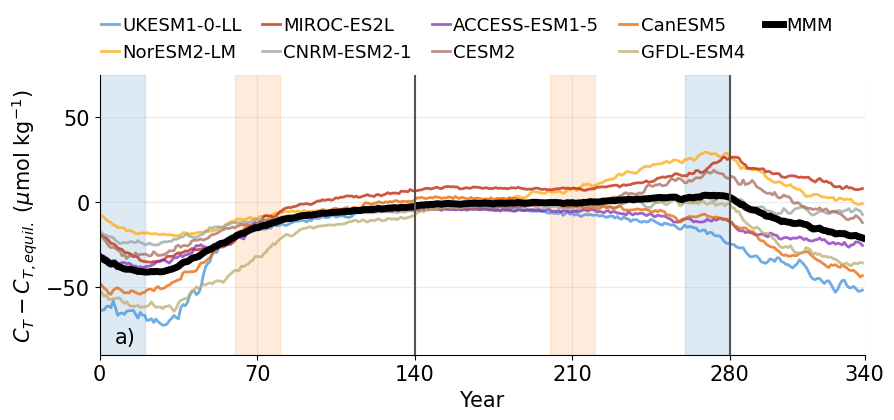

In [12]:
fig, ax = Plotter._plot_regional_time_series_without_smoothing(run_params,CT_diseq_reg_mean,'central Arctic',unit_label='$C_T - C_{T,equil.}$ ($\mu$mol kg$^{-1}$)',ylims=[-90,75])#,ylims=[-30,80])


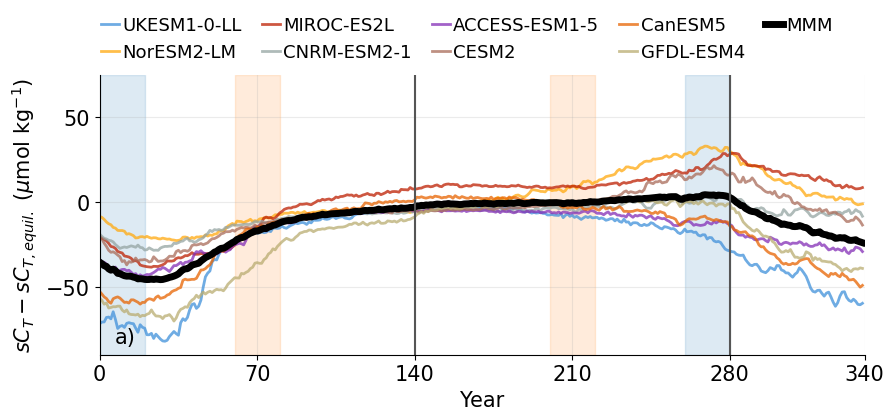

In [13]:
fig, ax = Plotter._plot_regional_time_series_without_smoothing(run_params,sCT_diseq_reg_mean,'central Arctic',unit_label='$sC_T - sC_{T,equil.}$ ($\mu$mol kg$^{-1}$)',ylims=[-90,75])#,ylims=[-30,80])


## Compute the temporal mean over years 210-280 (second half of the rampdown) for the central Arctic and save it for use in correlation plots

In [14]:
reg_of_choice = 'central Arctic'
meanslice = slice(210,280)
sCT_diseq_reg_mean_rampdown_2nd_half_means = sCT_diseq_reg_mean[reg_of_choice].isel(year=meanslice).mean(dim='year')
sCT_diseq_reg_mean_rampdown_2nd_half_means.attrs['unit'] = 'mumol per kg'
sCT_diseq_reg_mean_rampdown_2nd_half_means.attrs['region'] = reg_of_choice
sCT_diseq_reg_mean_rampdown_2nd_half_means.attrs['decription'] = f'regional mean sCT disequilibrium (sCT - sCT_equilibrium) averaged over year={meanslice}'
sCT_diseq_reg_mean_rampdown_2nd_half_means.to_netcdf(f'../05_plots_datasets/fig04_sCT_disequilibrium_{reg_of_choice}_rampdown_means_2nd_half.nc')

# Make some supplementary plots

## First calculate the spatially explicit sCT disequilibrium

In [15]:
sCT_disequilibrium_ds = xr.Dataset()
for key in run_params.keys(): # loop over runs
    sCT_disequilibrium_ds[key] = ds_data_sal_norm[key][temporal_resolution] - CT_equil_sal_norm[key][temporal_resolution]

## Plot initial sCT disequilibrium across models (year 0)

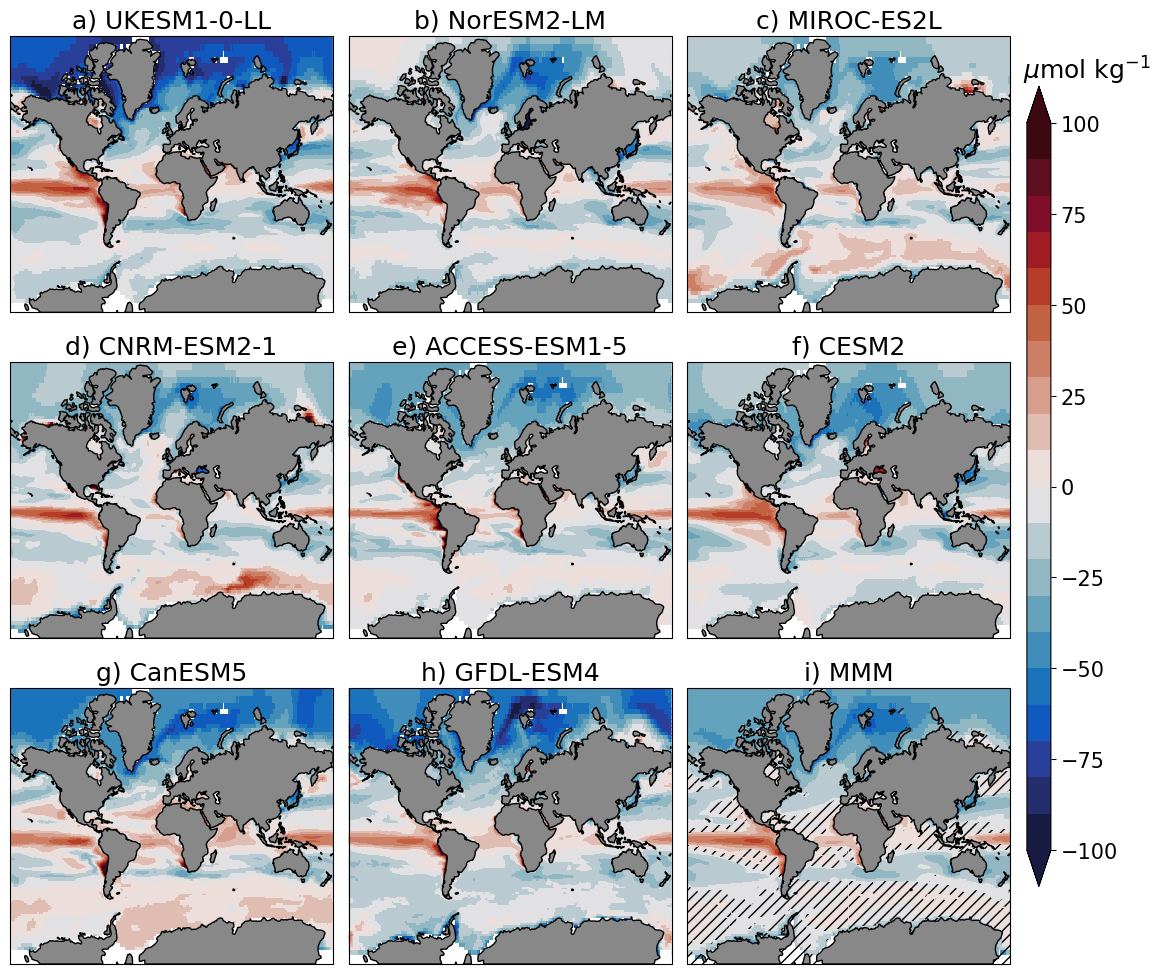

In [16]:
def _plot_initial_sCT_disequilibrium_across_models(run_params,disequil_ds,temporal_resolution):

    # Create 3x3 subplot figure with Cartopy projection
    fig, axes = plt.subplots(3, 3, subplot_kw={'projection': ccrs.Mercator()}, figsize=(12, 10)) # Choosing Mercator to have a bigger view of the Arctic
    panel_labs = ['a','b','c','d','e','f','g','h','i'] 

    # Loop over model runs
    idx = -1
    for key in run_params.keys():
        idx+=1
        row, col = divmod(idx, 3)
        ax = axes[row, col]
        ax.set_title(f'{panel_labs[idx]}) {run_params[key].model}')

        # get the disequilibrium at year=0 and plot it
        data_to_plot = disequil_ds[key].isel(year=0)
        pcm = ax.pcolormesh(data_to_plot.lon, data_to_plot.lat, data_to_plot, transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=plt.get_cmap('cmo.balance',20))

    # plot the multi-model mean in the last subplot
    sCT_diseq_mmm, sCT_diseq_agreement = MMFuncs._calc_multimodel_mean_and_agreement(disequil_ds)
    pcm = axes[-1,-1].pcolormesh(sCT_diseq_mmm.lon, sCT_diseq_mmm.lat, sCT_diseq_mmm.isel(year=0), transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=plt.get_cmap('cmo.balance',20))
    axes[-1,-1].contourf(sCT_diseq_mmm.lon, sCT_diseq_mmm.lat, sCT_diseq_agreement.isel(year=0), colors=[(0.5,0.5,0.5,0),(0.5,0.5,0.5,0)],levels=[-0.5,0.5,1.5],hatches=['///',None],transform=ccrs.PlateCarree()); 
    axes[-1,-1].set_title("i) MMM")
    
    for axi in axes.flatten():
        axi.set_global()
        axi.add_feature(cartopy.feature.LAND, zorder=2, edgecolor='black',facecolor='#888888')

    # Finishing touches
    plt.tight_layout()
    plt.subplots_adjust(right=0.86,wspace=0.02)
    cbax = fig.add_axes([0.87,0.1,0.02,0.8])
    plt.colorbar(pcm,cax=cbax,extend='both')
    cbax.set_title(r'            $\mu$mol kg$^{-1}$')
    #plt.savefig('plots_for_egu2025/post_EGU/sCT_initial_deficit_individual_models.png',transparent=True,dpi=300)
    plt.show()

    return fig, ax 

fig, ax = _plot_initial_sCT_disequilibrium_across_models(run_params,sCT_disequilibrium_ds,temporal_resolution)


## Plot multimodel mean evolution of the multi-model mean sCT disequilibrium

Compute the time slice means and the model agreement.... (here, i provide the sCT_disequilibrium_ds simply twice, since i do not include preindustrial values).....


/tmp/ipykernel_479038/2261957639.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


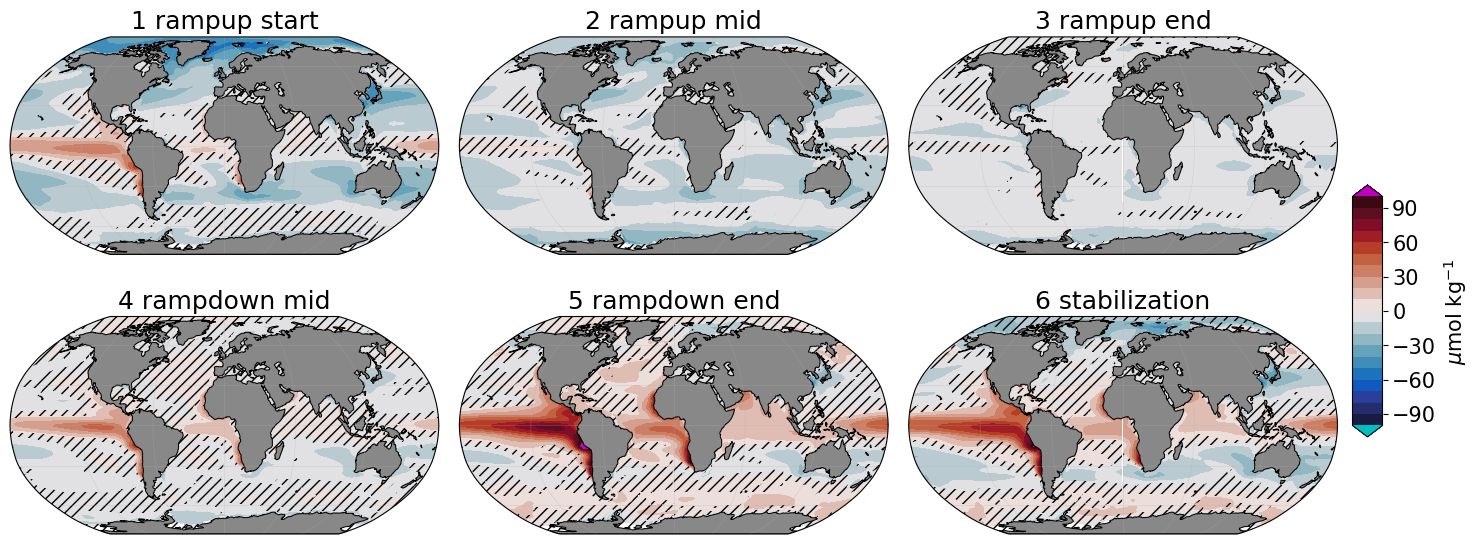

In [17]:
def _plot_global_time_slice_averages_sCT_disequilibrium(sCT_disequilibrium_ts_mmm,sCT_disequilibrium_ts_agreement,including_preindustrial=False,unit=None,vmin=-100,vmax=100):

    time_slices = list(sCT_disequilibrium_ts_mmm.keys())
    #print(time_slices)
    if including_preindustrial == False:
        time_slices.remove('0_preindustrial')
        #print(time_slices)

    # initialize colormap
    vmin,vmax,cmap = vmin,vmax,plt.get_cmap('cmo.balance',20)
    cmap.set_over('m')
    cmap.set_under('c')

    # set up figure
    fig = plt.figure(figsize=(15,6))
    ax = np.empty((len(time_slices)),dtype='object')
    for mdx,time_slice in enumerate(sorted(time_slices)):
        ax[mdx] = fig.add_subplot(2,3,mdx+1,projection=ccrs.Robinson())#NorthPolarStereo

        # get the data and plot it
        mmm_to_plot = sCT_disequilibrium_ts_mmm[time_slice]
        agreement_to_plot = sCT_disequilibrium_ts_agreement[time_slice]
        c0 = ax[mdx].contourf(mmm_to_plot.lon,mmm_to_plot.lat,mmm_to_plot,levels=np.linspace(vmin,vmax,21),cmap=cmap,transform=ccrs.PlateCarree(),extend='both')
        ax[mdx].contourf(agreement_to_plot.lon, agreement_to_plot.lat, agreement_to_plot, colors=[(0.5,0.5,0.5,0),(0.5,0.5,0.5,0)],levels=[-0.5,0.5,1.5],hatches=['///',None],transform=ccrs.PlateCarree()); 

        # beautify
        ax[mdx].add_feature(cartopy.feature.LAND, zorder=2, edgecolor='k',facecolor='#888888',linewidth=0.75)
        ax[mdx].gridlines(alpha=0.3,linestyle='-',linewidth=0.5)
        ax[mdx].set_global()
        ax[mdx].set_title(time_slices[mdx].replace('_',' '))

    cbax0 = fig.add_axes([0.91,0.24,0.02,0.42])
    #cbar0 = plt.colorbar(c0,cax=cbax0,label='-')
    cbar0 = plt.colorbar(c0,cax=cbax0,label=unit,extend='both')
    plt.tight_layout()
    plt.subplots_adjust(right=0.9)
    #plt.savefig(f'plots_for_egu2025/post_EGU/maps_sCT_deficit_global_time_slice_averages.png',dpi=300,transparent=True)
    plt.show()
    return fig, ax 


print('Compute the time slice means and the model agreement.... (here, i provide the sCT_disequilibrium_ds simply twice, since i do not include preindustrial values).....')
sCT_disequilibrium_ts_mmm, sCT_disequilibrium_ts_agreement = MMFuncs._calc_time_slice_averages(sCT_disequilibrium_ds,sCT_disequilibrium_ds,temporal_resolution,time_slices='standard',time_slice_type='absolute_value')

fig, ax = _plot_global_time_slice_averages_sCT_disequilibrium(sCT_disequilibrium_ts_mmm,
                                                    sCT_disequilibrium_ts_agreement,
                                                    including_preindustrial=False,
                                                    unit=r'$\mu$mol kg$^{-1}$',
                                                    vmin = -100,
                                                    vmax = 100)


## Plot the sCT difference between the end of rampdown (260-280) and the start of rampup (0-20) to see where there are largest changes

In [18]:
print('First calculate the time slice differences in sCT for each model......')
sCT_time_slice_difference = xr.Dataset()
for key in run_params.keys(): # loop over runs
    rampdown_end = ds_data_sal_norm[key][temporal_resolution].isel(year=slice(260,280)).mean(dim='year')
    rampup_start = ds_data_sal_norm[key][temporal_resolution].isel(year=slice(0,20)).mean(dim='year')
    sCT_time_slice_difference[key] = rampdown_end - rampup_start

print('.... and compute the multi-model mean and agreement')
sCT_time_slice_difference_mmm, sCT_time_slice_difference_agreement = MMFuncs._calc_multimodel_mean_and_agreement(sCT_time_slice_difference, da_name=None, agreement_type = 'sign', agreement_thresh='at_least_80percent_agree')

First calculate the time slice differences in sCT for each model......
.... and compute the multi-model mean and agreement


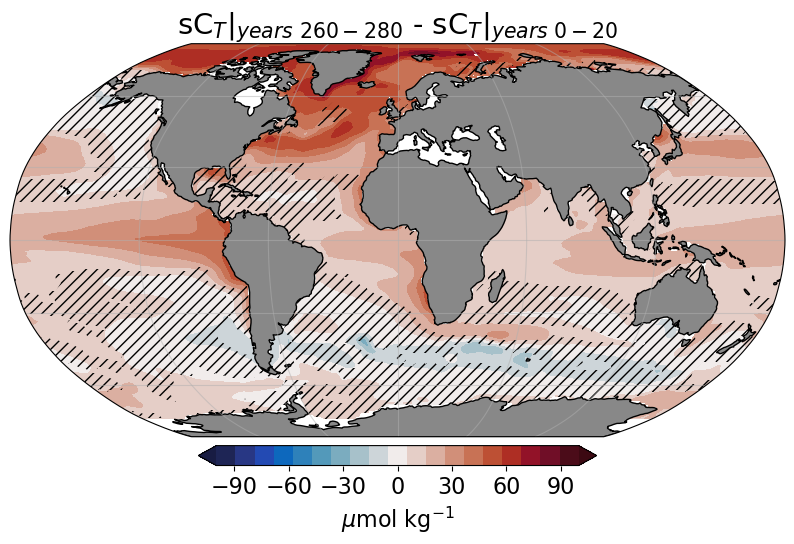

In [19]:
fig, ax = Plotter.plot_global_map(sCT_time_slice_difference_mmm,[],
                        -100,100,20,
                        plt.get_cmap('cmo.balance'),
                        [-90,-60,-30,0,30,60,90],
                        'both',
                        r'$\mu$mol kg$^{-1}$',
                        r'sC$_T|_{years\,\, 260-280}$ - sC$_T|_{years\,\, 0-20}$',
                        agreement=sCT_time_slice_difference_agreement)

## Calculate the hysteresis areas for sCT_equilibrium

In [20]:
print('First get the spatially explicit sCT_equilibrium......')
sCT_equil_ds = xr.Dataset()
for key in run_params.keys(): # loop over runs
    sCT_equil_ds[key] = CT_equil_sal_norm[key][temporal_resolution]

First get the spatially explicit sCT_equilibrium......


In [21]:
print('Now calculate the hysteresis areas......')
hyst_dict = HystFuncs._calc_hysteresis_areas_3D_multimodel(run_params,sCT_equil_ds,temporal_resolution,ds_atmCO2)

Now calculate the hysteresis areas......
Calculating hysteresis area for model UKESM1-0-LL (key 2)...
Calculating hysteresis area for model NorESM2-LM (key 3)...
Calculating hysteresis area for model MIROC-ES2L (key 4)...
Calculating hysteresis area for model CNRM-ESM2-1 (key 5)...
Calculating hysteresis area for model ACCESS-ESM1-5 (key 6)...
Calculating hysteresis area for model CESM2 (key 7)...
Calculating hysteresis area for model CanESM5 (key 8)...
Calculating hysteresis area for model GFDL-ESM4 (key 9)...


In [22]:
print('Calculating multimodel mean and model agreement ...')
h_mmm,  h_agree  = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='hysteresis_area',            agreement_type='mean_bigger_than_std')
hn_mmm, hn_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='normalized_hysteresis_area', agreement_type='mean_bigger_than_std')
hs_mmm, hs_agree = MMFuncs._calc_multimodel_mean_and_agreement(hyst_dict, da_name='signed_hysteresis_area', agreement_type='sign', agreement_thresh='at_least_80percent_agree')

Calculating multimodel mean and model agreement ...


## Plot the hysteresis areas for sCT_equilibrium as global maps

In [23]:
print('get the standard locations for masking/marking.......')
set_of_loc_reg = MiscDataGetter._standard_set_of_regions_locations()
print('Chosen locations: ', set_of_loc_reg)

get the standard locations for masking/marking.......
Chosen locations:  ['Global Ocean', [88, 260], [60, 90], 'central Arctic']


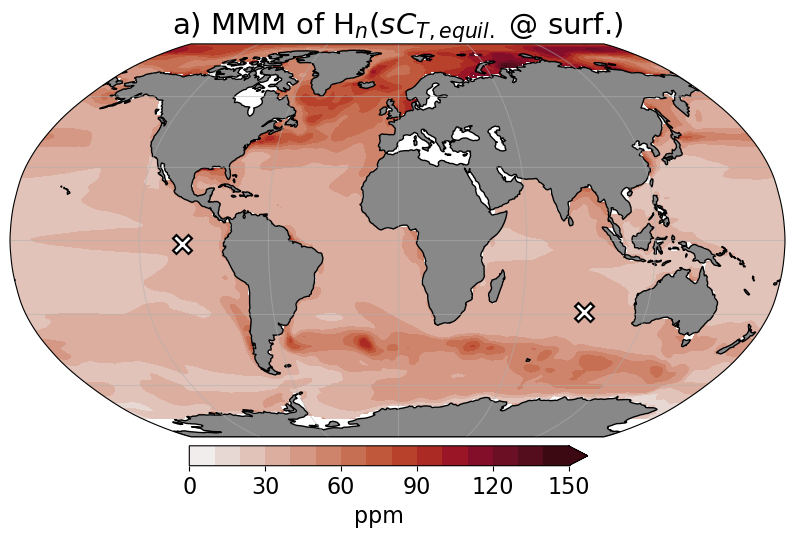

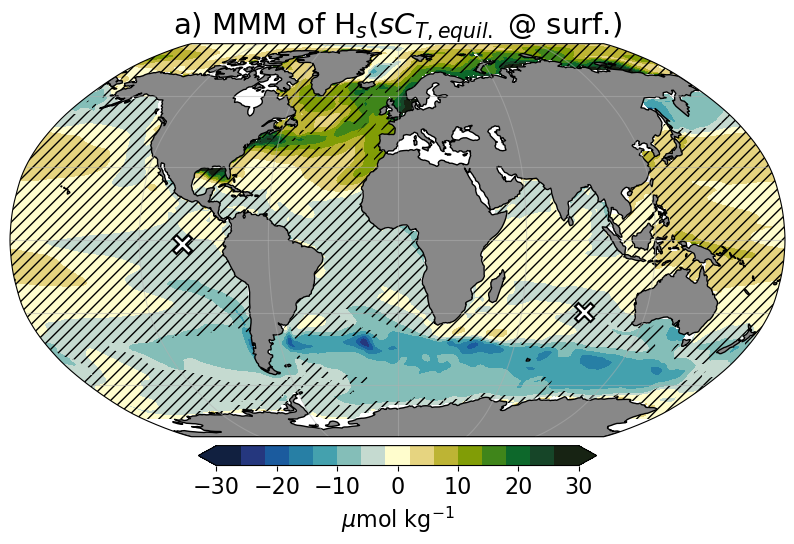

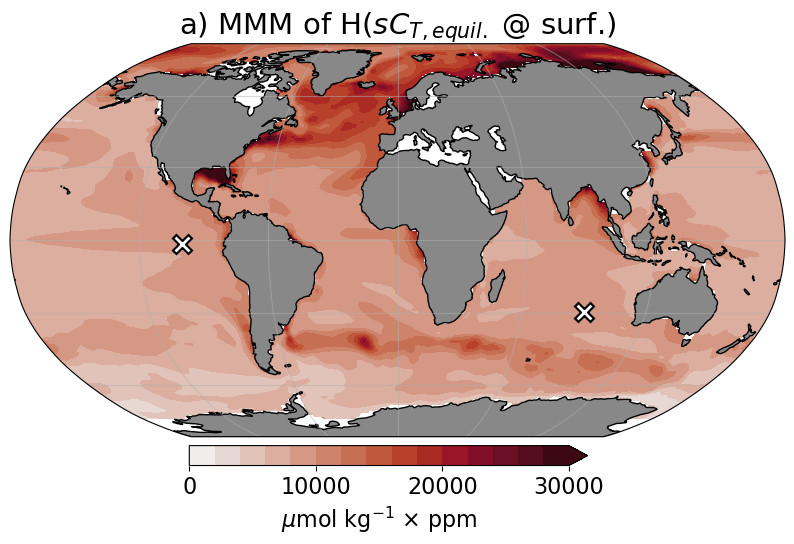

In [24]:
fig, ax = Plotter.plot_global_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=150,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,30,60,90,120,150],
                                  extend='max',
                                  clabel='ppm',
                                  title=r'a) MMM of H$_n$($sC_{T,equil.}$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_normalized_mmm_sCT_equilibrium.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_global_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-30,
                                  vmax=30,
                                  nlevs=16,
                                  cticks = [-30,-20,-10,0,10,20,30],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',15),
                                  extend='both',
                                  clabel=r'$\mu$mol kg$^{-1}$',
                                  title=r'a) MMM of H$_s$($sC_{T,equil.}$ @ surf.)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_signed_mmm_sCT_equilibrium.png',dpi=300,transparent=True)

fig, ax = Plotter.plot_global_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=30000,
                                  nlevs=16,
                                  cticks = [0,10000,20000,30000],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  extend='max',
                                  clabel=r'$\mu$mol kg$^{-1}$ $\times$ ppm',
                                  title=r'a) MMM of H($sC_{T,equil.}$ @ surf.)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_global_hysteresis_full_mmm_sCT_equilibrium.png',dpi=300,transparent=True)



## Plot the hysteresis areas for sCT_equilibrium as Arctic maps

Plot the multimodel mean hysteresis areas - for the Arctic....


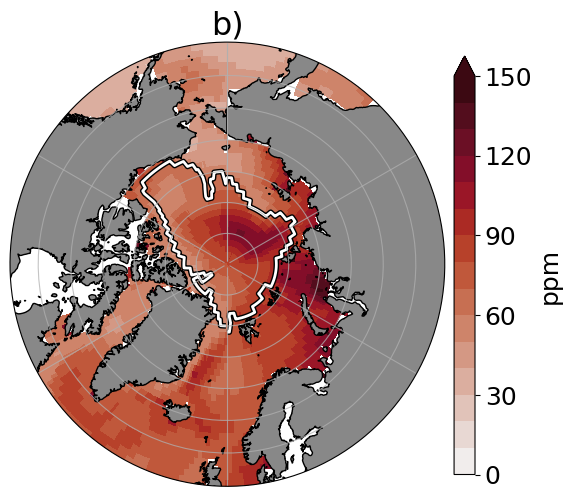

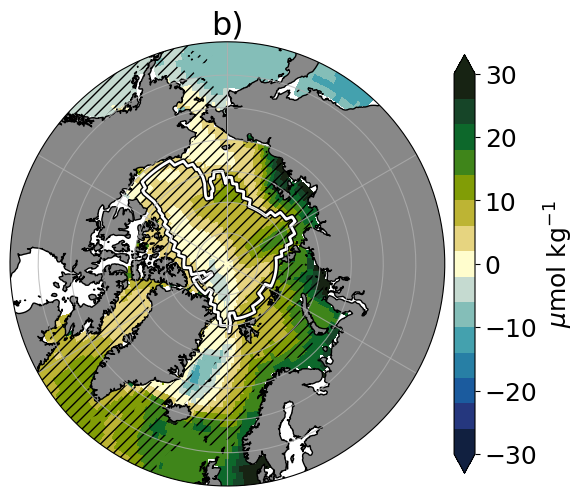

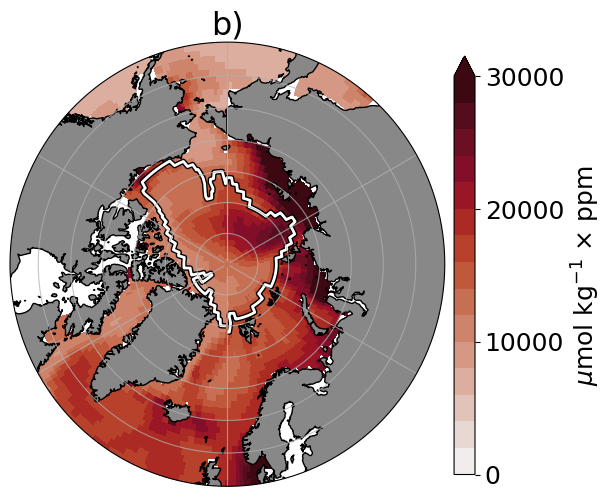

In [25]:
print('Plot the multimodel mean hysteresis areas - for the Arctic....')

fig, ax = Plotter.plot_arctic_map(hn_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=150,
                                  nlevs=16,
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  cticks = [0,30,60,90,120,150],
                                  extend='max',
                                  clabel='ppm',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_normalized_mmm_sCT_equilibrium.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_arctic_map(hs_mmm,
                                  set_of_loc_reg,
                                  vmin=-30,
                                  vmax=30,
                                  nlevs=16,
                                  cticks = [-30,-20,-10,0,10,20,30],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.delta',15),
                                  extend='both',
                                  clabel=r'$\mu$mol kg$^{-1}$',
                                  title=r'b)',
                                  agreement=hs_agree)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_signed_mmm_sCT_equilibrium.png',dpi=300,transparent=True)


fig, ax = Plotter.plot_arctic_map(h_mmm,
                                  set_of_loc_reg,
                                  vmin=0,
                                  vmax=30000,
                                  nlevs=16,
                                  cticks = [0,10000,20000,30000],#,30,60,90,120,150],
                                  cmap=plt.get_cmap('cmo.amp',15),
                                  extend='max',
                                  clabel=r'$\mu$mol kg$^{-1}$ $\times$ ppm',
                                  title=r'b)',
                                  agreement=None)
if savefigs == True:
    fig.savefig(f'{plot_dir}/map_arctic_hysteresis_full_mmm_sCT_equilibrium.png',dpi=300,transparent=True)


## Compute the regional mean hysteresis areas

In [26]:
print('Compute the regional hysteresis areas....')
regional_mean_normalized_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'normalized_hysteresis_area')
regional_mean_signed_hysteresis_areas = MMFuncs._calc_regional_means(run_params,set_of_loc_reg, hyst_dict, 'signed_hysteresis_area')

Compute the regional hysteresis areas....


## Save the central Arctic hysteresis areas

In [27]:
region_to_save = 'central Arctic'
ds_hn = regional_mean_normalized_hysteresis_areas[region_to_save]
ds_hs = regional_mean_signed_hysteresis_areas[region_to_save]
              
ds_hn.attrs['unit'] = 'ppm'
ds_hn.attrs['name'] = 'normalized hysteresis area'
ds_hn.attrs['region'] = f'{region_to_save}'

ds_hs.attrs['unit'] = 'mumol kg-1'
ds_hs.attrs['name'] = 'signed hysteresis area'
ds_hs.attrs['region'] = f'{region_to_save}'

############### SAVE THE AMOC hysteresis areas #################
ds_hn.to_netcdf(f'../05_plots_datasets/fig04_sCT_equilibrium_{region_to_save}_normalized_hysteresis_area.nc')
ds_hs.to_netcdf(f'../05_plots_datasets/fig04_sCT_equilibrium_{region_to_save}_signed_hysteresis_area.nc')

## Compare the sign-aware hysteresis of sCT_equil with the sign-aware hysteresis area of sCT

In [32]:
hs_sCT_equil = regional_mean_signed_hysteresis_areas['central Arctic']
hs_sCT = xr.open_dataset('../05_plots_datasets/fig04_sCT_central Arctic_signed_hysteresis_area.nc')


In [35]:
print('Per model: fraction of Hs explained by sCT disequilibrium. Calculated as "(1 - H_s(sCT_equil)/H_s(sCT))*100%"')
print('if H_s(sCT_equil) is negative (which it is for 4 models), the contribution is smaller than 0%, i.e., even negative')
print('in these cases the hysteresis due to the evolving disequilibrium even turns an otherwise quicker recovery of sCT into a slower one.')
print('')

all_Hs_sCT = []
all_Hs_sCT_equil = []
all_ratios = []
for key in run_params.keys():   
    ratio = (1-hs_sCT_equil[key].values/hs_sCT[key].values)*100   # % of the hysteresis in sCT explainable due to the disequilibrium
    print(f'{run_params[key].model}: {ratio:.2f}%,     Hs(sCT)={hs_sCT[key].values:.1f} mumol kg-1,      Hs(sCT_equil)={hs_sCT_equil[key].values:.1f} mumol kg-1')
    all_ratios.append(ratio)
    all_Hs_sCT.append(hs_sCT[key].values)
    all_Hs_sCT_equil.append(hs_sCT_equil[key].values)

print('')
print('------ Calculating numbers for manuscript text--------')
print(f'Hs(sCT): {np.mean(all_Hs_sCT):.2f}+-{np.std(all_Hs_sCT):.2f}mumol kg-1')
print(f'Hs(sCT_equil): {np.mean(all_Hs_sCT_equil):.2f}+-{np.std(all_Hs_sCT_equil):.2f}mumol kg-1')
print(f'{np.mean(all_ratios):.2f}+-{np.std(all_ratios):.2f}% of Hs(sCT) can be explained by the disequilibrium')


Per model: fraction of Hs explained by sCT disequilibrium. Calculated as "(1 - H_s(sCT_equil)/H_s(sCT))*100%"
if H_s(sCT_equil) is negative (which it is for 4 models), the contribution is smaller than 0%, i.e., even negative
in these cases the hysteresis due to the evolving disequilibrium even turns an otherwise quicker recovery of sCT into a slower one.

UKESM1-0-LL: 47.25%,     Hs(sCT)=35.0 mumol kg-1,      Hs(sCT_equil)=18.5 mumol kg-1
NorESM2-LM: 113.50%,     Hs(sCT)=15.3 mumol kg-1,      Hs(sCT_equil)=-2.1 mumol kg-1
MIROC-ES2L: 130.93%,     Hs(sCT)=15.1 mumol kg-1,      Hs(sCT_equil)=-4.7 mumol kg-1
CNRM-ESM2-1: 32.15%,     Hs(sCT)=27.0 mumol kg-1,      Hs(sCT_equil)=18.3 mumol kg-1
ACCESS-ESM1-5: 168.17%,     Hs(sCT)=5.8 mumol kg-1,      Hs(sCT_equil)=-3.9 mumol kg-1
CESM2: 117.61%,     Hs(sCT)=11.6 mumol kg-1,      Hs(sCT_equil)=-2.0 mumol kg-1
CanESM5: 68.37%,     Hs(sCT)=23.6 mumol kg-1,      Hs(sCT_equil)=7.5 mumol kg-1
GFDL-ESM4: 76.48%,     Hs(sCT)=36.4 mumol kg-1,      Hs